# Support Vector Machine (SVM) with Breast Cancer Dataset

This notebook demonstrates the use of **Support Vector Machines (SVM)** for classifying tumors in the Breast Cancer dataset.

## What is an SVM?

Support Vector Machines are powerful supervised learning models for classification. An SVM finds the **hyperplane** that best separates data points from two classes.

It maximizes the **margin**, which is the distance between the hyperplane and the nearest points from each class (support vectors).

## Step 1: Load the Breast Cancer Dataset

In [1]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=31
)

# Normalize (Standardize) features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Step 3: Train an SVM Model

We use the `SVC` class from `sklearn.svm` with default kernel (RBF).

In [2]:
from sklearn.svm import SVC

model = SVC(probability=True)
model.fit(X_train, y_train)

SVC(probability=True)

## Step 4: Evaluate the Model

In [3]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    ConfusionMatrixDisplay, classification_report, roc_curve, auc
)

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9766081871345029
Precision: 0.972972972972973
Recall: 0.9908256880733946
F1 Score: 0.9818181818181818

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.95      0.97        62
           1       0.97      0.99      0.98       109

    accuracy                           0.98       171
   macro avg       0.98      0.97      0.97       171
weighted avg       0.98      0.98      0.98       171



### What is a Confusion Matrix?

A **confusion matrix** is a summary of prediction results:

|                 | Predicted Positive | Predicted Negative |
|-----------------|--------------------|--------------------|
| Actual Positive | True Positive (TP) | False Negative (FN)|
| Actual Negative | False Positive (FP)| True Negative (TN) |

- Accuracy, Precision, Recall, F1 Score are all derived from this table.

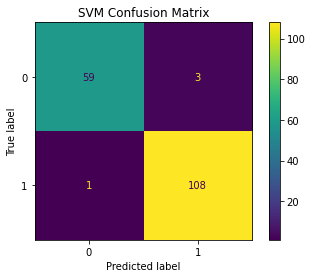

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)
plt.title('SVM Confusion Matrix')
plt.show()

### What is an ROC Curve?

The **ROC Curve** shows the trade-off between True Positive Rate (Recall) and False Positive Rate.
The **AUC (Area Under Curve)** summarizes the performance into a single number.

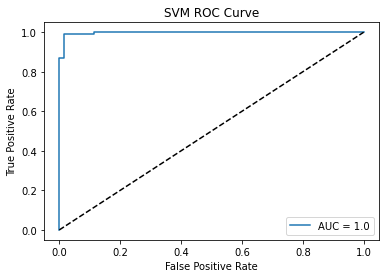

In [5]:
y_proba = model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label='AUC = ' + str(round(roc_auc, 2)))
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('SVM ROC Curve')
plt.legend()
plt.show()